# libraries

In [28]:
import numpy as np 
import pandas as  pd 

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC 
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc)
    

import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')



# data

In [2]:
np.random.seed(143)

n_samples = 1000
age = np.random.randint(18, 65, n_samples)
age

array([32, 43, 35, 51, 52, 64, 60, 36, 25, 47, 44, 47, 59, 19, 39, 34, 28,
       50, 31, 43, 30, 39, 39, 47, 38, 48, 33, 34, 45, 63, 44, 41, 51, 36,
       36, 24, 39, 48, 24, 34, 55, 57, 25, 38, 35, 27, 44, 64, 58, 21, 25,
       22, 33, 28, 63, 47, 40, 31, 20, 56, 51, 28, 52, 28, 56, 41, 21, 20,
       30, 42, 47, 64, 53, 41, 49, 43, 19, 18, 51, 48, 60, 51, 49, 29, 43,
       42, 38, 40, 21, 41, 56, 28, 45, 46, 51, 31, 64, 28, 32, 31, 36, 51,
       61, 23, 37, 27, 47, 29, 62, 41, 35, 24, 54, 31, 36, 31, 51, 48, 47,
       41, 22, 30, 24, 53, 48, 27, 48, 62, 21, 39, 60, 51, 48, 36, 41, 63,
       47, 48, 62, 30, 49, 18, 38, 43, 28, 30, 52, 48, 38, 64, 21, 46, 43,
       39, 52, 42, 28, 39, 25, 47, 21, 45, 34, 21, 42, 58, 18, 22, 25, 30,
       42, 40, 53, 18, 35, 18, 24, 28, 52, 48, 45, 41, 52, 36, 56, 62, 47,
       30, 22, 48, 40, 62, 24, 46, 24, 61, 45, 44, 61, 38, 29, 26, 51, 20,
       27, 22, 64, 58, 51, 51, 38, 48, 53, 41, 47, 32, 53, 40, 46, 54, 45,
       53, 39, 64, 18, 57

In [3]:
salary = np.random.randint(30000, 120000, n_samples)
salary

array([ 58488,  97504,  65369,  76814, 102849,  49812,  56729,  66028,
        38862, 105064,  34169,  50215,  92384,  41875,  39317,  69168,
        48647, 117973, 105217,  82853,  89453,  45244,  37351,  75945,
        43600,  60957,  62019,  37409, 109461,  76716, 103715,  73019,
        50530, 115016,  72712,  66937,  53286,  86193,  33590,  54791,
        47982,  36052,  71873,  75946,  60518,  72451,  41386,  78174,
       116980,  60755,  49307,  74431,  30393,  32832,  83698,  95484,
        43440,  77050,  71844,  86501,  97050,  99328,  68096,  47053,
        52414,  46349, 111828,  61045,  90179,  97648, 103832,  59701,
        67531,  59373,  36792,  63802,  32794,  94516,  42327,  88339,
        44861, 113224,  47149,  40353, 108136,  60146, 112222,  65530,
        40741,  51937, 114553,  71181,  80588,  67717,  34786,  66418,
       100496,  30259,  99650,  80207,  51508,  45997,  60532,  52012,
       102339,  74708,  34943,  62798,  35030,  64199,  48001,  79639,
      

In [4]:
tenure = np.random.randint(1,10, n_samples)
tenure

array([2, 9, 3, 5, 2, 1, 6, 5, 8, 3, 6, 7, 4, 4, 4, 4, 9, 2, 1, 2, 3, 6,
       4, 1, 3, 2, 4, 2, 9, 5, 8, 9, 4, 9, 1, 8, 4, 2, 2, 7, 8, 7, 5, 6,
       3, 7, 6, 5, 3, 1, 2, 2, 9, 9, 4, 5, 5, 6, 9, 1, 7, 7, 9, 9, 8, 3,
       5, 9, 7, 5, 4, 4, 9, 9, 7, 8, 5, 6, 7, 4, 9, 6, 9, 9, 4, 9, 1, 3,
       5, 1, 9, 4, 2, 4, 4, 8, 5, 3, 5, 4, 8, 9, 1, 9, 5, 2, 5, 1, 2, 6,
       1, 5, 7, 3, 9, 6, 4, 6, 7, 6, 4, 5, 2, 2, 2, 1, 8, 7, 6, 4, 6, 2,
       9, 8, 3, 2, 6, 4, 4, 9, 9, 6, 3, 8, 6, 1, 5, 5, 8, 2, 7, 2, 9, 8,
       4, 6, 2, 8, 1, 6, 6, 6, 7, 7, 9, 2, 8, 9, 1, 2, 8, 2, 7, 5, 9, 1,
       1, 6, 2, 4, 3, 1, 9, 9, 6, 1, 9, 4, 1, 3, 7, 9, 3, 3, 1, 9, 5, 2,
       4, 9, 6, 6, 2, 2, 8, 4, 5, 1, 9, 4, 8, 7, 5, 4, 3, 9, 7, 4, 4, 6,
       4, 6, 1, 9, 6, 2, 6, 8, 7, 6, 7, 8, 4, 3, 7, 2, 8, 8, 9, 5, 7, 2,
       2, 9, 6, 3, 7, 8, 4, 6, 5, 7, 8, 7, 2, 4, 7, 2, 5, 2, 5, 5, 7, 5,
       6, 8, 2, 2, 3, 7, 8, 4, 7, 8, 8, 7, 6, 8, 9, 9, 1, 8, 4, 5, 7, 3,
       4, 5, 7, 6, 9, 9, 7, 8, 9, 4, 4, 9, 2, 9, 4,

In [5]:
product_type = np.random.choice(['A','B','C','D'], n_samples)
product_type

array(['B', 'B', 'C', 'B', 'A', 'D', 'D', 'A', 'D', 'B', 'C', 'D', 'B',
       'B', 'B', 'B', 'B', 'D', 'C', 'B', 'B', 'A', 'A', 'A', 'B', 'C',
       'C', 'A', 'B', 'D', 'D', 'A', 'D', 'C', 'C', 'C', 'C', 'B', 'A',
       'C', 'B', 'A', 'A', 'C', 'C', 'B', 'C', 'A', 'B', 'A', 'C', 'B',
       'D', 'B', 'A', 'C', 'D', 'A', 'A', 'B', 'B', 'C', 'D', 'D', 'A',
       'B', 'C', 'C', 'D', 'C', 'B', 'A', 'B', 'B', 'D', 'A', 'D', 'A',
       'B', 'C', 'C', 'A', 'D', 'D', 'A', 'C', 'B', 'D', 'A', 'B', 'C',
       'D', 'C', 'C', 'C', 'C', 'A', 'A', 'A', 'A', 'C', 'D', 'D', 'D',
       'C', 'C', 'D', 'B', 'B', 'A', 'C', 'A', 'D', 'C', 'A', 'C', 'C',
       'D', 'B', 'D', 'C', 'A', 'B', 'B', 'A', 'A', 'D', 'C', 'C', 'D',
       'D', 'D', 'A', 'D', 'C', 'A', 'C', 'B', 'D', 'B', 'C', 'D', 'D',
       'D', 'B', 'D', 'D', 'C', 'C', 'D', 'B', 'B', 'A', 'A', 'C', 'B',
       'A', 'C', 'D', 'A', 'D', 'B', 'A', 'C', 'A', 'B', 'B', 'D', 'B',
       'B', 'C', 'D', 'C', 'C', 'D', 'A', 'B', 'C', 'D', 'C', 'B

In [6]:
churn_probability = (
    0.05 * (65-age)/ 47 + 
    0.05 * (120000 -salary) / 90000  + 
    0.1 * (10 -tenure) / 9
)
churn_probability

array([0.15816861, 0.04701314, 0.14004323, 0.09444139, 0.11224701,
       0.14005716, 0.08491415, 0.11639106, 0.10985208, 0.10522449,
       0.11446876, 0.09125171, 0.08839187, 0.15900561, 0.13915013,
       0.12788539, 0.09011337, 0.10597245, 0.14438299, 0.13293037,
       0.13198238, 0.11363513, 0.14024235, 0.14362394, 0.14894563,
       0.13977566, 0.13292089, 0.1677515 , 0.03824271, 0.08172988,
       0.05360987, 0.06274358, 0.12015473, 0.04473106, 0.15712217,
       0.09531869, 0.13138957, 0.12575566, 0.18051147, 0.10253928,
       0.07287052, 0.08848175, 0.12484597, 0.09764229, 0.14273823,
       0.10017498, 0.11045931, 0.07985605, 0.08690236, 0.1797224 ,
       0.17071597, 0.15994968, 0.09493533, 0.09889948, 0.0889621 ,
       0.08832449, 0.12468463, 0.10447577, 0.08573678, 0.12818502,
       0.06097695, 0.08417948, 0.05377645, 0.09099892, 0.06934447,
       0.14422691, 0.10690407, 0.09173623, 0.0871346 , 0.09244142,
       0.09479783, 0.10122994, 0.05302651, 0.07032469, 0.09658

In [7]:
churn_probability += np.where(product_type ==  'D', 0.2, 0)
churn_probability

array([0.15816861, 0.04701314, 0.14004323, 0.09444139, 0.11224701,
       0.34005716, 0.28491415, 0.11639106, 0.30985208, 0.10522449,
       0.11446876, 0.29125171, 0.08839187, 0.15900561, 0.13915013,
       0.12788539, 0.09011337, 0.30597245, 0.14438299, 0.13293037,
       0.13198238, 0.11363513, 0.14024235, 0.14362394, 0.14894563,
       0.13977566, 0.13292089, 0.1677515 , 0.03824271, 0.28172988,
       0.25360987, 0.06274358, 0.32015473, 0.04473106, 0.15712217,
       0.09531869, 0.13138957, 0.12575566, 0.18051147, 0.10253928,
       0.07287052, 0.08848175, 0.12484597, 0.09764229, 0.14273823,
       0.10017498, 0.11045931, 0.07985605, 0.08690236, 0.1797224 ,
       0.17071597, 0.15994968, 0.29493533, 0.09889948, 0.0889621 ,
       0.08832449, 0.32468463, 0.10447577, 0.08573678, 0.12818502,
       0.06097695, 0.08417948, 0.25377645, 0.29099892, 0.06934447,
       0.14422691, 0.10690407, 0.09173623, 0.2871346 , 0.09244142,
       0.09479783, 0.10122994, 0.05302651, 0.07032469, 0.29658

In [8]:
churn_probability = np.clip(churn_probability + np.random.normal(0, 0.1, n_samples), 0, 1)
churn_probability

array([0.09591924, 0.        , 0.39905324, 0.        , 0.        ,
       0.53369826, 0.16652014, 0.        , 0.34291203, 0.10610023,
       0.01970313, 0.39586881, 0.03836131, 0.24760999, 0.05100658,
       0.22354317, 0.14776205, 0.24934393, 0.01162838, 0.09358083,
       0.24629714, 0.        , 0.05941014, 0.15404996, 0.08432993,
       0.15982356, 0.22881435, 0.17944113, 0.09533516, 0.33482352,
       0.30885116, 0.        , 0.37465195, 0.03577817, 0.00405124,
       0.30940607, 0.01364288, 0.26875899, 0.3025791 , 0.16759651,
       0.03250096, 0.16653478, 0.09985196, 0.01206292, 0.09071188,
       0.08248337, 0.02116501, 0.06919986, 0.27131806, 0.20168441,
       0.08848562, 0.12147893, 0.29347453, 0.25145044, 0.        ,
       0.17216848, 0.30953978, 0.13835691, 0.05843246, 0.082332  ,
       0.08313035, 0.        , 0.32107634, 0.37438645, 0.14823269,
       0.05428885, 0.17482216, 0.09082282, 0.36105974, 0.13847421,
       0.08311444, 0.09711532, 0.        , 0.        , 0.49877

In [9]:
churn = (churn_probability > 0.5).astype(int)
churn

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [10]:
df_churn = pd.DataFrame({
    'Age': age,
    'Salary': salary,
    'Tenure': tenure,
    'Product_Type': product_type,
    'Churn': churn
})
df_churn

,Age,Salary,Tenure,Product_Type,Churn
0,32,58488,2,B,0
1,43,97504,9,B,0
2,35,65369,3,C,0
3,51,76814,5,B,0
4,52,102849,2,A,0
...,...,...,...,...,...
995,51,90894,8,B,0
996,54,99973,3,C,0
997,20,53795,6,C,0
998,54,110796,1,A,0


In [11]:
df_churn.Churn.value_counts(normalize=True)

Churn
0    0.994
1    0.006
Name: proportion, dtype: float64

In [12]:
df_churn.Churn.value_counts()

Churn
0    994
1      6
Name: count, dtype: int64

In [13]:
x = df_churn.drop('Churn', axis=1)
x

,Age,Salary,Tenure,Product_Type
0,32,58488,2,B
1,43,97504,9,B
2,35,65369,3,C
3,51,76814,5,B
4,52,102849,2,A
...,...,...,...,...
995,51,90894,8,B
996,54,99973,3,C
997,20,53795,6,C
998,54,110796,1,A


In [14]:
y = df_churn['Churn']
y

0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: Churn, Length: 1000, dtype: int64

In [15]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.2,random_state=143)
xtrain

,Age,Salary,Tenure,Product_Type
325,28,116425,1,D
918,31,81743,7,D
424,27,70500,8,C
598,26,35725,4,C
853,33,114979,6,A
...,...,...,...,...
162,34,52572,7,A
545,29,74205,8,C
529,19,59583,7,A
153,39,49190,8,A


In [16]:
ytrain

325    0
918    0
424    0
598    0
853    0
      ..
162    0
545    0
529    0
153    0
590    0
Name: Churn, Length: 800, dtype: int64

In [22]:
numerical_features = ['Age','Salary', 'Tenure']
categorical_features = ['Product_Type']


In [23]:
# create a processor using coluntransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # keep other columns as it is if there are any
)
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['Age', 'Salary', 'Tenure']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Product_Type'])])

In [24]:
pipeline_lg = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=143, solver='liblinear'))
    ]
)
pipeline_lg

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Salary', 'Tenure']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Type'])])),
                ('classifier',
                 LogisticRegression(random_state=143, solver='liblinear'))])

In [25]:
pipeline_lg.fit(xtrain, ytrain)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Salary', 'Tenure']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Type'])])),
                ('classifier',
                 LogisticRegression(random_state=143, solver='liblinear'))])

In [27]:
y_pre_lg = pipeline_lg.predict(xtest)
y_prob_lg = pipeline_lg.predict_proba(xtest)[:,1] # onlytake probabiliteis for the positive values
y_prob_lg

array([0.00347464, 0.00497622, 0.0065306 , 0.0070022 , 0.00426227,
       0.00322127, 0.00838134, 0.02012521, 0.00609949, 0.0084164 ,
       0.00869164, 0.00548221, 0.00540914, 0.00482339, 0.0071861 ,
       0.00391582, 0.00781747, 0.00778458, 0.00382326, 0.01722731,
       0.00593934, 0.00870337, 0.00332109, 0.01254037, 0.00507748,
       0.00475974, 0.00356754, 0.00450322, 0.00279259, 0.01007185,
       0.00470351, 0.01730478, 0.01203077, 0.00778268, 0.00958564,
       0.00680372, 0.0035083 , 0.01175047, 0.01211749, 0.00465258,
       0.00288926, 0.00559232, 0.02544083, 0.01854156, 0.00289296,
       0.00348728, 0.04447525, 0.00546102, 0.01227625, 0.00885262,
       0.002409  , 0.00978824, 0.00653148, 0.01580701, 0.0041241 ,
       0.00960277, 0.0211117 , 0.00695032, 0.0159792 , 0.00738711,
       0.02979036, 0.00721818, 0.03212135, 0.00630453, 0.00758327,
       0.002873  , 0.00185709, 0.01029037, 0.00673867, 0.00448028,
       0.02234167, 0.00318054, 0.00317475, 0.00426279, 0.00824

In [29]:
# evaluate the model accuracy, others..
accuracy_lg = accuracy_score(ytest, y_pre_lg)
precisionLg = precision_score(ytest, y_pre_lg)
recallLG = recall_score(ytest, y_pre_lg)
fscore = f1_score(ytest, y_pre_lg)
confmatrixLg = confusion_matrix(ytest, y_pre_lg)
accuracy_lg, precisionLg, recallLG, fscore, confmatrixLg

(0.995,
 0.0,
 0.0,
 0.0,
 array([[199,   0],
        [  1,   0]]))

# regression problem

In [30]:
n_samples_reg = 500
sq_footage = np.random.randint(800, 3000, n_samples_reg)
num_bedrooms = np.random.randint(2,6, n_samples_reg)
location_score = np.random.rand(n_samples_reg) * 10 # 0 -10 scale
location_score

array([0.12556125, 3.1738715 , 4.52060209, 0.38834823, 6.64675959,
       0.39234272, 7.66295163, 7.15641662, 3.32927262, 8.07103996,
       6.38257414, 8.9519848 , 8.60973185, 6.24300072, 7.52577803,
       5.18519152, 4.85428904, 9.08399704, 9.18738994, 0.12217933,
       4.02147679, 7.64907855, 7.62514561, 2.25960573, 7.51660711,
       4.32986212, 7.84094665, 9.74223251, 0.7358159 , 0.06033595,
       5.93271069, 9.80779367, 2.2351235 , 9.96202929, 6.23024708,
       9.96375701, 8.03457869, 4.74293062, 8.22439888, 5.04490726,
       1.24632979, 0.07948198, 7.18896111, 6.70440351, 0.51972678,
       6.5569611 , 6.08014103, 9.3075593 , 4.22550828, 7.29799419,
       0.63371166, 6.03361432, 0.31489295, 1.37786137, 4.94735622,
       2.18784014, 9.08271269, 6.93975523, 6.86538254, 4.10688143,
       8.32529909, 4.48985098, 3.22362157, 1.40022829, 0.37755412,
       1.09719441, 6.14149059, 9.94367308, 8.97995549, 7.69552746,
       8.8132622 , 2.63105995, 3.3359161 , 4.6118673 , 4.05257

In [31]:
price = (sq_footage * 100 + num_bedrooms * 5000 + location_score * 10000 +
         np.random.normal(0, 50000, n_samples_reg)) 
price

array([156372.39382083, 391283.79024392, 152213.91407367, 260568.00055709,
       389958.81822077, 148318.33498382, 189970.70593648, 270073.34550549,
       241581.2566943 , 243002.4274177 , 312330.78798533, 154063.36976406,
       177839.20945268, 147735.30205846, 165708.18910068, 360644.73682302,
       209812.52890578, 399999.96410881, 239593.84231151, 248558.15658881,
       324273.25123047, 326563.87238739, 423320.84948969, 145965.87948643,
       293916.97155011, 242022.4188261 , 230334.12611333, 133298.8652608 ,
       129144.83788596, 290549.85775135, 232877.64886425, 494030.39588971,
       126811.42939467, 355526.68736988, 220885.85183513, 271688.84854674,
       234412.76786013, 359497.36687605, 244345.01818234, 216343.00523747,
       298103.06398847, 157808.79128659, 442439.18555917, 205991.76771231,
       196591.79119705, 173109.38963902, 246054.03027465, 385600.20628897,
       252151.51905514, 279094.7396352 , 180966.65911922, 317105.38948945,
       238855.26023096, 2

In [32]:
price = np.maximum(0, price)
price

array([156372.39382083, 391283.79024392, 152213.91407367, 260568.00055709,
       389958.81822077, 148318.33498382, 189970.70593648, 270073.34550549,
       241581.2566943 , 243002.4274177 , 312330.78798533, 154063.36976406,
       177839.20945268, 147735.30205846, 165708.18910068, 360644.73682302,
       209812.52890578, 399999.96410881, 239593.84231151, 248558.15658881,
       324273.25123047, 326563.87238739, 423320.84948969, 145965.87948643,
       293916.97155011, 242022.4188261 , 230334.12611333, 133298.8652608 ,
       129144.83788596, 290549.85775135, 232877.64886425, 494030.39588971,
       126811.42939467, 355526.68736988, 220885.85183513, 271688.84854674,
       234412.76786013, 359497.36687605, 244345.01818234, 216343.00523747,
       298103.06398847, 157808.79128659, 442439.18555917, 205991.76771231,
       196591.79119705, 173109.38963902, 246054.03027465, 385600.20628897,
       252151.51905514, 279094.7396352 , 180966.65911922, 317105.38948945,
       238855.26023096, 2

In [33]:
df_housing = pd.DataFrame({
    'Sq_Footage': sq_footage,
    'Num_Bedrooms': num_bedrooms,
    'Location_Score': location_score,
    'Price': price
})

df_housing

,Sq_Footage,Num_Bedrooms,Location_Score,Price
0,1455,2,0.125561,156372.393821
1,2884,2,3.173872,391283.790244
2,1374,2,4.520602,152213.914074
3,2248,3,0.388348,260568.000557
4,2647,4,6.646760,389958.818221
...,...,...,...,...
495,2360,3,3.908536,215377.004925
496,1595,4,4.195383,284605.778287
497,2109,3,7.041153,358473.488999
498,1590,2,9.885410,255346.252064


In [35]:
X_reg = df_housing.drop('Price', axis=1)
y_reg = df_housing['Price']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

X_train_reg

,Sq_Footage,Num_Bedrooms,Location_Score
249,922,5,4.712192
433,2231,3,4.758458
19,2410,5,0.122179
322,2819,5,0.356789
332,2189,3,8.947943
...,...,...,...
106,2694,5,2.230044
270,2189,5,3.517256
348,999,2,4.081718
435,865,2,3.976577


In [36]:
y_train_reg

249    188545.039833
433    270289.173968
19     248558.156589
322    387133.191952
332    344420.260516
           ...      
106    328596.510699
270    232268.146127
348    220873.515104
435    140323.415616
102    344575.426780
Name: Price, Length: 400, dtype: float64

In [44]:

reg_processor = ColumnTransformer(
        transformers=[
            ('num',StandardScaler(), ['Sq_Footage','Num_Bedrooms','Location_Score'])
        ],
        remainder='passthrough'
)
reg_processor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['Sq_Footage', 'Num_Bedrooms',
                                  'Location_Score'])])

In [45]:
reg_pipeline = Pipeline(
    steps=[
        ('preprocessor', reg_processor),
        ('regressor', LinearRegression())
        
    ]
)
reg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Sq_Footage', 'Num_Bedrooms',
                                                   'Location_Score'])])),
                ('regressor', LinearRegression())])

In [46]:
reg_pipeline.fit(X_train_reg, y_train_reg)
reg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Sq_Footage', 'Num_Bedrooms',
                                                   'Location_Score'])])),
                ('regressor', LinearRegression())])

In [47]:
ypredlrreg = reg_pipeline.predict(X_test_reg)
ypredlrreg

array([206935.55495279, 174108.96129829, 371892.21462614, 178604.21045214,
       165537.35829547, 178394.57081423, 183498.70415482, 247868.08660456,
       318516.25424273, 227094.39516919, 209060.12781562, 199343.02463588,
       337281.09579005, 152285.930413  , 423613.66537276, 391949.13359409,
       293632.2231692 , 194727.0469245 , 344640.46005928, 324450.78251591,
       186089.46672597, 335407.87743147, 318191.89356515, 220552.98354252,
       289759.4923759 , 303945.44523361, 301826.4102221 , 339505.45556782,
       330732.38182535, 350138.49946929, 331749.35958174, 333880.97668728,
       251029.10864494, 241810.28276618, 191884.8347087 , 376115.996885  ,
       276950.67084102, 262449.94947782, 319192.61046956, 323329.56570267,
       326856.18005767, 206730.83944613, 259411.72618658, 262211.30478188,
       376411.35037836, 275585.7071694 , 151770.72614219, 206121.499736  ,
       261739.63050449, 363862.71592272, 173385.08553082, 410417.0571647 ,
       184366.76660463, 1

In [50]:
mseReg = mean_squared_error(y_test_reg, ypredlrreg)
rmseReg = np.sqrt(mseReg)
r2_reg = r2_score(y_test_reg, ypredlrreg)
mseReg, rmseReg, r2_reg

(2356143495.962731, np.float64(48540.12253757432), 0.6969895055984809)

# Unsupervised learning

In [51]:
x_churn_preprocessed = preprocessor.fit_transform(x)
x_churn_preprocessed

array([[-0.6672654 , -0.62128117, -1.21818949, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.1596746 ,  0.919902  ,  1.52107374, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44173631, -0.34947264, -0.82686617, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.56938176, -0.80666082,  0.34710378, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.98661459,  1.44495343, -1.60951281, ...,  0.        ,
         0.        ,  0.        ],
       [-0.6672654 , -1.1976448 , -0.82686617, ...,  0.        ,
         1.        ,  0.        ]])

In [52]:
x.shape

(1000, 4)

In [53]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans

KMeans(n_clusters=3, n_init=10, random_state=42)

In [54]:
kmeans.fit(x_churn_preprocessed)
kmeans

KMeans(n_clusters=3, n_init=10, random_state=42)

In [55]:
df_churn['clusters'] = kmeans.labels_
df_churn

,Age,Salary,Tenure,Product_Type,Churn,clusters
0,32,58488,2,B,0,1
1,43,97504,9,B,0,0
2,35,65369,3,C,0,1
3,51,76814,5,B,0,1
4,52,102849,2,A,0,2
...,...,...,...,...,...,...
995,51,90894,8,B,0,0
996,54,99973,3,C,0,2
997,20,53795,6,C,0,0
998,54,110796,1,A,0,2


In [56]:
df_churn.groupby('clusters')[numerical_features].mean()

,Age,Salary,Tenure
clusters,,,
0,42.350482,60163.173633,7.694534
1,41.768072,57882.472892,2.900602
2,38.761905,101648.142857,4.921569


In [57]:
df_churn.groupby('clusters')['Churn'].value_counts(normalize=True).unstack()

Churn,0,1
clusters,,
0,0.993569,0.006431
1,0.993976,0.006024
2,0.994398,0.005602


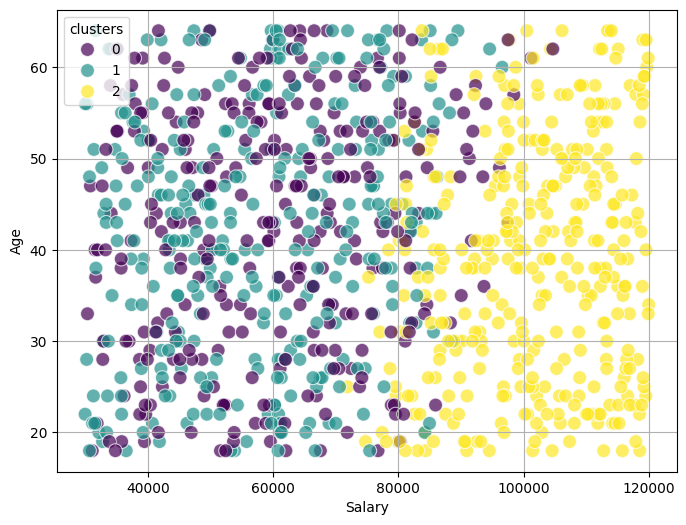

In [61]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Salary', y='Age',hue='clusters', data=df_churn,  palette='viridis', s=100, alpha=0.7)
plt.grid(True)
plt.show()